# Extragalactic Unsupervised Discovery

This notebook demonstrates how to run an Unsupervised Discovery workflow with a collection of HSC galaxies. 
It extends the shorter [Astronomy Unsupervised](unsupervised_image_extragalactic.ipynb) example by adding interactive visualization of latent spaces, vector database search, and cutout inspection.

This notebook describes the full runnable science workflow:

1. Acquire an HSC dataset from Zenodo
2. Initialize and configure Hyrax
3. Train an autoencoder model
4. Run inference to produce latent representations
5. Reduce dimensionality with UMAP
6. Interactively explore the latent space with `h.visualize()`
7. Search for similar objects with a vector database
8. Identify anomalies using nearest-neighbour distances

## The data

This example uses roughly 1000 [Hyper Suprime-Cam](https://www.naoj.org/Projects/HSC/) (HSC) cutouts, each 8 arcseconds on a side in `g`, `i`, and `r` bands. These cutouts were acquired previously from the HSC cutout service and cached in [Zenodo](https://zenodo.org/records/14498536) for easier access.

## The model

This demonstration uses `HyraxAutoencoderV2`, an example model built into Hyrax. Because this is an unsupervised workflow, the goal is not classification against fixed labels, but learning a compact latent representation that can be used for similarity search and anomaly discovery.The source code for this model is available on [GitHub](https://github.com/lincc-frameworks/hyrax/blob/main/src/hyrax/models/hyrax_autoencoderv2.py).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Acquire an HSC dataset from Zenodo

We acquired a small sample of HSC cutouts and cached them in Zenodo for convenience.
We'll pull those down now using [pooch](https://www.fatiando.org/pooch/).

In [2]:
import pooch

file_path = pooch.retrieve(
    url="doi:10.5281/zenodo.14498536/hsc_demo_data.zip",
    known_hash="md5:1be05a6b49505054de441a7262a09671",
    fname="example_hsc_new.zip",
    path="../../data",
    processor=pooch.Unzip(extract_dir="."),
)

data_dir = "../../data/hsc_8asec_1000"

## Initialize Hyrax

We begin by creating an instance of `Hyrax` and editing the configuration. The [configuration system](https://hyrax.readthedocs.io/en/latest/configuration_system.html) in Hyrax is substantial and comes with reasonable defaults. We'll make a few changes to specify:

- The model we intend to train
- The number of training epochs and batch size
- The data that we intend to use

The `data_request` defines what data each stage of the workflow should use. Here we define separate train and validation splits. You can learn more about data requests in the [data requests notebook](../notebooks/data_requests.ipynb).

In [ ]:
from hyrax import Hyrax

h = Hyrax()

h.set_config("model.name", "HyraxAutoencoderV2")
h.set_config("train.epochs", 20)
h.set_config("data_loader.batch_size", 32)

data_request_definition = {
    "train": {
        "data": {
            "dataset_class": "HSCDataset",
            "data_location": data_dir,
            "primary_id_field": "object_id",
            "split_fraction": 0.8,
        },
    },
    "validate": {
        "data": {
            "dataset_class": "HSCDataset",
            "data_location": data_dir,
            "primary_id_field": "object_id",
            "split_fraction": 0.2,
        },
    },
}
h.set_config("data_request", data_request_definition)

## Train an autoencoder model

With the configuration set correctly, we begin training.

In [ ]:
model = h.train()

The results of training are persisted by default in a timestamped directory and include:
- Full copy of the complete configuration
- The trained model weights
- Checkpoint files
- Training metric records

### Monitoring training

Hyrax automatically emits metrics to both TensorBoard and MLflow for real-time model performance evaluation. You can view these from the terminal or from a notebook.

For a detailed walkthrough of how to activate and use these tools, see [Using TensorBoard and MLflow](../notebooks/using_tensorboard_and_mlflow.ipynb).

![TensorBoard screenshot](../_static/screenshots/tensorboard_checkpoint_val_loss.png)

## Process data with the trained model

Now that we have a trained model, we can use it for inference to produce lower-dimensional representations of the data.

We'll tweak the configuration before running inference to:
- Increase the batch size for faster processing
- Specify the data to process (in this case the same data used for training, but without splits)

In [ ]:
h.config["data_loader"]["batch_size"] = 512

data_request_definition = {
    "infer": {
        "data": {
            "dataset_class": "HSCDataset",
            "data_location": data_dir,
            "primary_id_field": "object_id",
        },
    },
}
h.set_config("data_request", data_request_definition)

inference_results = h.infer()

The results are placed in a timestamped directory containing:
- Inference results in [Lance](https://lancedb.github.io/lance/) format
- A complete copy of the configuration used
- A copy of the model weights used to produce the results

You can read more about working with results in the [working with results data](working_with_results_data.ipynb) notebook.

## Reduce dimensionality with UMAP

In order to visualize the latent space, we reduce its dimensionality. [UMAP](https://umap-learn.readthedocs.io/en/latest/) compresses the 64-dimensional autoencoder output down to 2 dimensions so we can plot and interact with it.

In [6]:
h.config["umap"]["UMAP"]["n_components"] = 2
h.umap()

[2026-03-27 18:13:08,743 hyrax.verbs.umap:INFO] Saving UMAP results to /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/results/20260327-181308-umap-QNSR
[2026-03-27 18:13:08,778 hyrax.verbs.umap:INFO] Fitting the UMAP
[2026-03-27 18:13:18,448 hyrax.verbs.umap:INFO] Saving fitted UMAP Reducer


Creating lower dimensional representation using UMAP::   0%|          | 0/2 [00:00<?, ?it/s]

[2026-03-28T01:13:21Z WARN  lance::dataset::write::insert] No existing dataset at /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/results/20260327-181308-umap-QNSR/lance_db/results.lance, it will be created
[2026-03-27 18:13:22,511 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 2 batches
[2026-03-27 18:13:22,530 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-03-27 18:13:22,530 hyrax.verbs.umap:INFO] Finished transforming all data through UMAP


Let's load the UMAP results and create a scatter plot of the latent space.

In [7]:
from hyrax.config_utils import find_most_recent_results_dir

results_dir = str(find_most_recent_results_dir(h.config, "umap"))
data_request_definition = {
    "analysis": {
        "umap": {
            "dataset_class": "ResultDataset",
            "data_location": results_dir,
            "primary_id_field": "object_id",
        },
    }
}
h.config["data_request"] = data_request_definition
umap_results = h.prepare()

[2026-03-27 18:13:22,602 hyrax.prepare:INFO] Finished Prepare


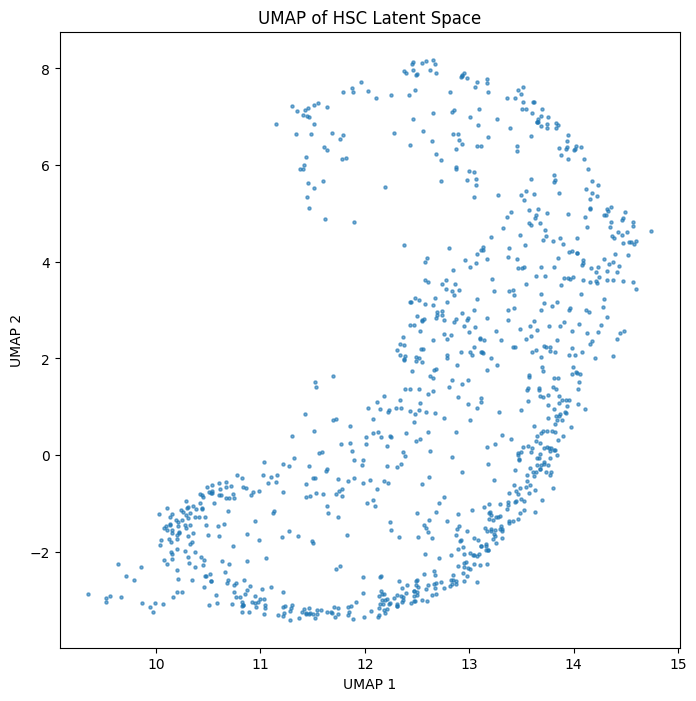

In [8]:
out = np.array([umap_results["analysis"][i]["umap"]["data"] for i in range(len(umap_results["analysis"]))])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(out[:, 0], out[:, 1], s=5, alpha=0.6)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of HSC Latent Space")
plt.show()

## Interactive visualization

Hyrax includes a built-in interactive visualization that overlays the UMAP scatter plot with a selection table and image panel. You can lasso-select, box-select, or tap on points to inspect individual objects.

We set the `filter_catalog` explicitly so that the visualize verb can access HSC metadata such as RA, Dec, and filenames.

[2026-03-27 18:13:28,435 hyrax.verbs.visualize:INFO] UMAP directory not specified at runtime. Reading from config values.
[2026-03-27 18:13:28,517 hyrax.datasets.hsc_dataset:INFO] Checking file dimensions to determine standard cutout size...
[2026-03-27 18:13:28,519 hyrax.datasets.fits_image_dataset:INFO] FitsImageDataset has 993 objects
[2026-03-27 18:13:28,535 hyrax.datasets.hsc_dataset:INFO] Processed 993 objects for pruning
[2026-03-27 18:13:29,099 hyrax.datasets.hsc_dataset:INFO] Checking file dimensions to determine standard cutout size...
[2026-03-27 18:13:29,102 hyrax.datasets.fits_image_dataset:INFO] FitsImageDataset has 993 objects
[2026-03-27 18:13:29,118 hyrax.datasets.hsc_dataset:INFO] Processed 993 objects for pruning
[2026-03-27 18:13:29,200 hyrax.datasets.hsc_dataset:INFO] Checking file dimensions to determine standard cutout size...
[2026-03-27 18:13:29,202 hyrax.datasets.fits_image_dataset:INFO] FitsImageDataset has 993 objects
[2026-03-27 18:13:29,217 hyrax.datasets.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
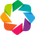

Row
    [0] HoloViews(DynamicMap, height=550, sizing_mode='fixed', width=550)
    [1] Column
        [0] HoloViews(DynamicMap, height=165, width=550)
        [1] HoloViews(DynamicMap)
        [2] Row
            [0] Button(button_type='primary', name='Resample Images')
            [1] LoadingSpinner(height=30, margin=(5, 10, 5, 0), width=30)

In [9]:
# Set data_request back to infer with HSCDataset for the visualize verb
data_request_definition = {
    "infer": {
        "data": {
            "dataset_class": "HSCDataset",
            "data_location": data_dir,
            "primary_id_field": "object_id",
        },
    },
}
h.set_config("data_request", data_request_definition)

# Explicitly point to the manifest so the visualize verb can access metadata
h.config["data_set"]["filter_catalog"] = str(Path(data_dir).resolve() / "manifest.fits")

h.config["visualize"]["display_images"] = True
h.config["general"]["data_dir"] = data_dir
h.config["visualize"]["fields"] = ["ra_data", "dec_data"]
h.config["visualize"]["torch_tensor_bands"] = [0]
h.config["visualize"]["rasterize_plot"] = False
h.config["visualize"]["color_column"] = "ra_data"
h.config["visualize"]["cmap"] = "plasma"

viz = h.visualize(make_lupton_rgb_opts={"stretch": 8, "Q": 5}, width=550, height=550)

## Calculate similarity with a vector database

Hyrax can save inference results into a [vector database](https://en.wikipedia.org/wiki/Vector_database) for fast nearest-neighbour lookups. The Lance file format readily supports this, so for each object we can efficiently find the most similar objects in latent space.

For a dedicated walkthrough of the vector database features, see the [vector database notebook](vector_db_demo.ipynb).

In [10]:
infer_dir = str(find_most_recent_results_dir(h.config, "infer"))
h.config["data_loader"]["batch_size"] = 512
h.save_to_database(input_dir=infer_dir)

[2026-03-27 18:13:32,454 hyrax.verbs.save_to_database:INFO] Saving vector database at /mmfs1/gscratch/dirac/aritrag/repos/hyrax/docs/pre_executed/results/20260327-181332-vector-db-6Ssf
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.34it/s]
[2026-03-27 18:13:34,154 hyrax.verbs.save_to_database:INFO] Vector database insertion complete. Total time: 0.210s for 2 batches


In [11]:
vdb_dir = str(find_most_recent_results_dir(h.config, "vector-db"))
conn = h.database_connection(database_dir=vdb_dir)

object_ids = list(inference_results.ids())
search_id = object_ids[0]
nearest_neighbours = conn.search_by_id(search_id, k=10)
nn_ids = nearest_neighbours[search_id]

print(f"Query object: {search_id}")
print(f"Nearest neighbours: {nn_ids}")

Query object: 36407329666631333
Nearest neighbours: ['36407329666631333', '37481140210127257', '38554242084003517', '38553975796029667', '39613505573244081', '38549874102260404', '39613754681353146', '36424926147659595', '39618565044729823', '38544904825103196']


## Visualize cutouts

Let's look at the query object alongside its nearest neighbours. Since the HSC data consists of individual FITS files per band, we load each band separately and composite them into an RGB image using astropy's [Lupton scaling](https://docs.astropy.org/en/stable/visualization/rgb.html).

In [12]:
import glob
from astropy.io import fits
from astropy.visualization import make_lupton_rgb


def load_hsc_rgb(object_id, data_directory, bands=("HSC-I", "HSC-R", "HSC-G")):
    """Load HSC FITS cutouts and return an RGB image using Lupton scaling."""
    data_directory = Path(data_directory).expanduser().resolve()
    images = []
    for band in bands:
        pattern = str(data_directory / f"{object_id}*_{band}.fits")
        found = glob.glob(pattern)
        if not found:
            raise FileNotFoundError(f"No file matching {pattern}")
        img = fits.getdata(found[0]).astype(float)
        valid = img[~np.isnan(img)]
        if len(valid) > 0:
            img[np.isnan(img)] = np.median(valid)
        else:
            img[:] = 0
        images.append(img)
    return make_lupton_rgb(*images, Q=10, stretch=0.5)


def plot_hsc_cutouts(object_ids, data_directory, title="HSC Cutouts"):
    """Plot a row of HSC RGB cutouts for the given object IDs."""
    n = len(object_ids)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, oid in zip(axes, object_ids):
        try:
            rgb = load_hsc_rgb(str(oid), data_directory)
            ax.imshow(rgb, origin="lower")
        except Exception as e:
            ax.text(
                0.5,
                0.5,
                f"Error:\n{e}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=7,
                color="red",
            )
        ax.set_title(f"{oid}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    return fig, axes

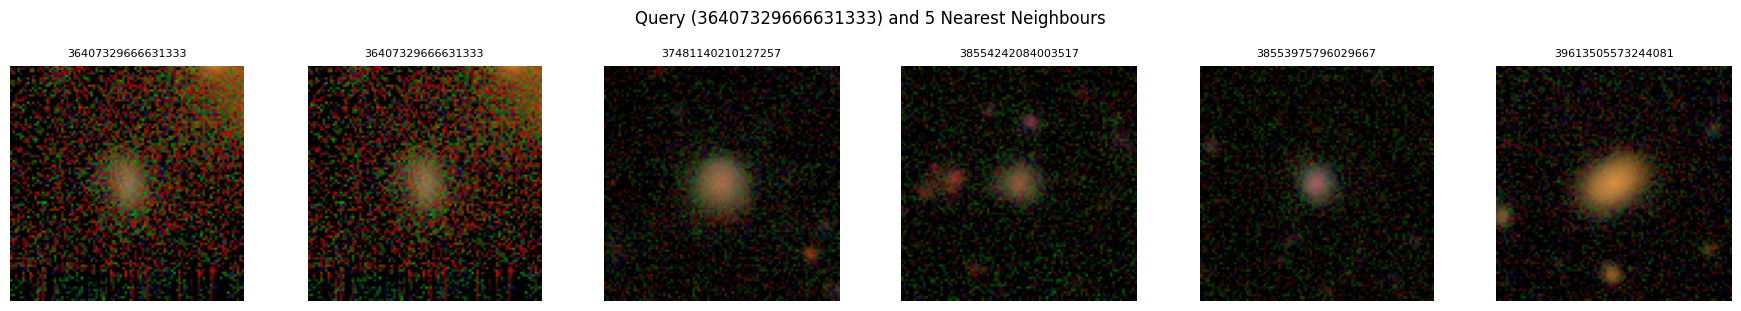

(<Figure size 1800x300 with 6 Axes>,
 array([<Axes: title={'center': '36407329666631333'}>,
        <Axes: title={'center': '36407329666631333'}>,
        <Axes: title={'center': '37481140210127257'}>,
        <Axes: title={'center': '38554242084003517'}>,
        <Axes: title={'center': '38553975796029667'}>,
        <Axes: title={'center': '39613505573244081'}>], dtype=object))

In [13]:
# Plot the query object and its 5 nearest neighbours side by side
plot_hsc_cutouts([search_id] + nn_ids[:5], data_dir, title=f"Query ({search_id}) and 5 Nearest Neighbours")

## Identify anomalies with nearest-neighbour distances

For each object, we find the L2 distances to its 5 nearest neighbours in the latent space. The median of those distances gives a single "outlier score" per object.

> Objects with unusually large median distances live far from any cluster in the latent space, making them candidates for anomalies — artifacts, rare morphologies, or blended sources.

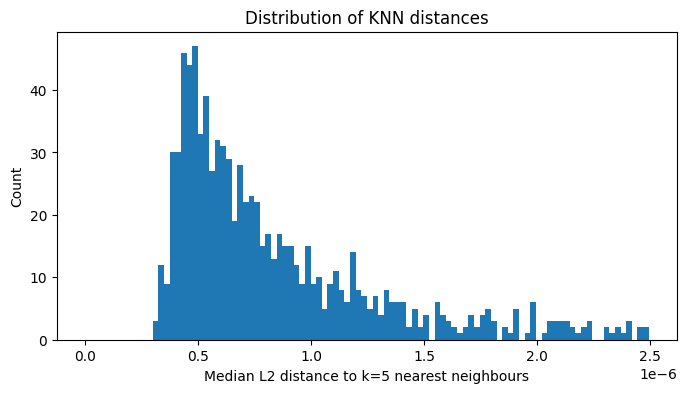

In [14]:
all_embeddings = [inference_results[i].flatten() for i in range(len(inference_results))]

knn_distances = []
for emb in all_embeddings:
    results = inference_results.table.search(emb).metric("L2").limit(6).to_list()
    dists = [r["_distance"] for r in results[1:]]  # skip self
    knn_distances.append(dists)

median_dist = np.median(knn_distances, axis=1)

plt.figure(figsize=(8, 4))
plt.hist(median_dist, bins=100, range=(0, np.mean(median_dist) * 2))
plt.xlabel("Median L2 distance to k=5 nearest neighbours")
plt.ylabel("Count")
plt.title("Distribution of KNN distances")
plt.show()

There appears to be a long tail in the distribution, indicating that a small number of objects have latent representations that are far from any cluster. Let's compare the most "normal" objects (smallest median distance) with the most "anomalous" (largest median distance).

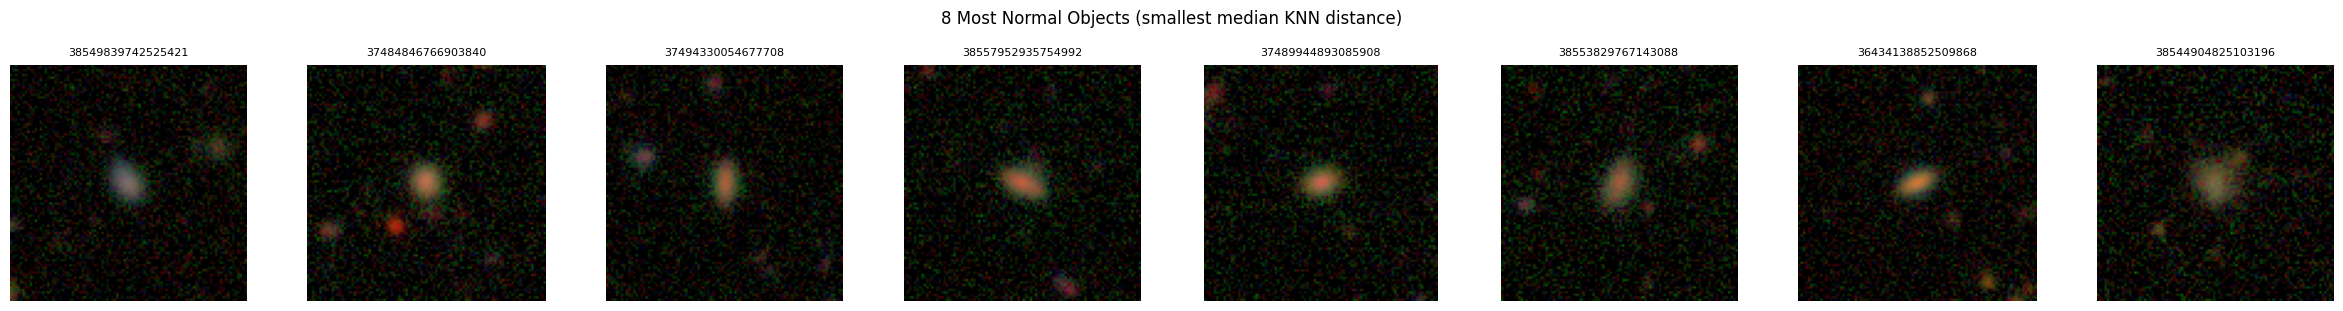

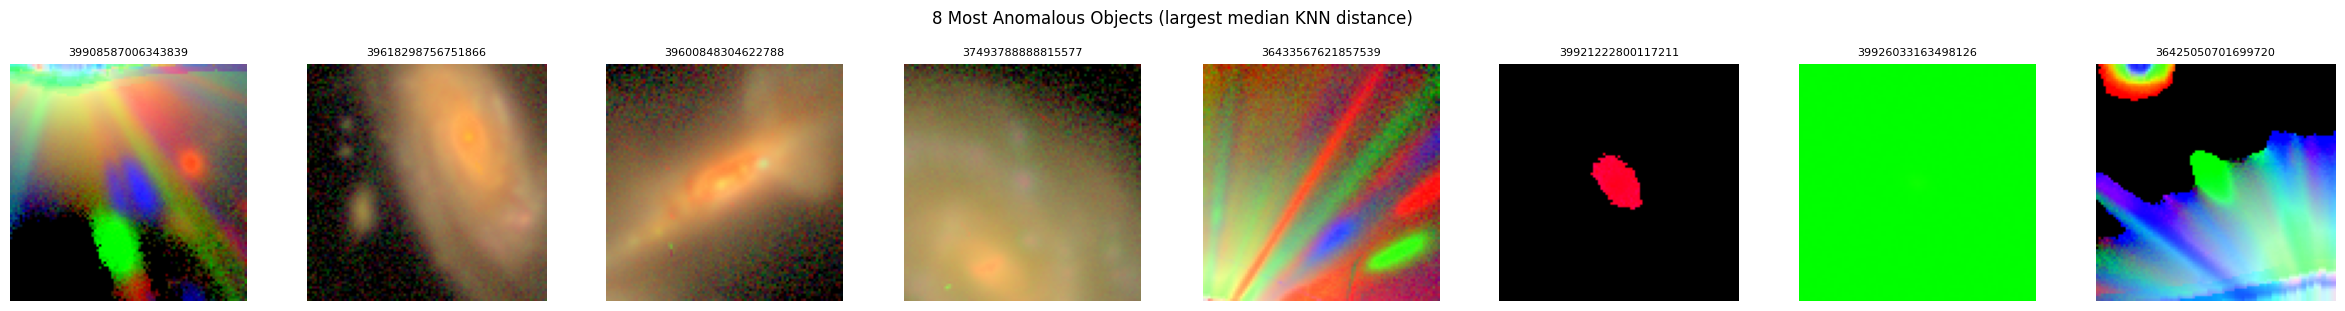

(<Figure size 2400x300 with 8 Axes>,
 array([<Axes: title={'center': '39908587006343839'}>,
        <Axes: title={'center': '39618298756751866'}>,
        <Axes: title={'center': '39600848304622788'}>,
        <Axes: title={'center': '37493788888815577'}>,
        <Axes: title={'center': '36433567621857539'}>,
        <Axes: title={'center': '39921222800117211'}>,
        <Axes: title={'center': '39926033163498126'}>,
        <Axes: title={'center': '36425050701699720'}>], dtype=object))

In [15]:
sorted_indices = np.argsort(median_dist)
normal_ids = [object_ids[i] for i in sorted_indices[:8]]
anomalous_ids = [object_ids[i] for i in sorted_indices[-8:]]

plot_hsc_cutouts(normal_ids, data_dir, title="8 Most Normal Objects (smallest median KNN distance)")
plot_hsc_cutouts(anomalous_ids, data_dir, title="8 Most Anomalous Objects (largest median KNN distance)")

The "normal" objects tend to be compact and isolated, while the "anomalous" objects tend to be extended, in crowded fields, or contain instrument artifacts.

We can overlay these two populations on the UMAP scatter plot to see how they separate in the latent space.

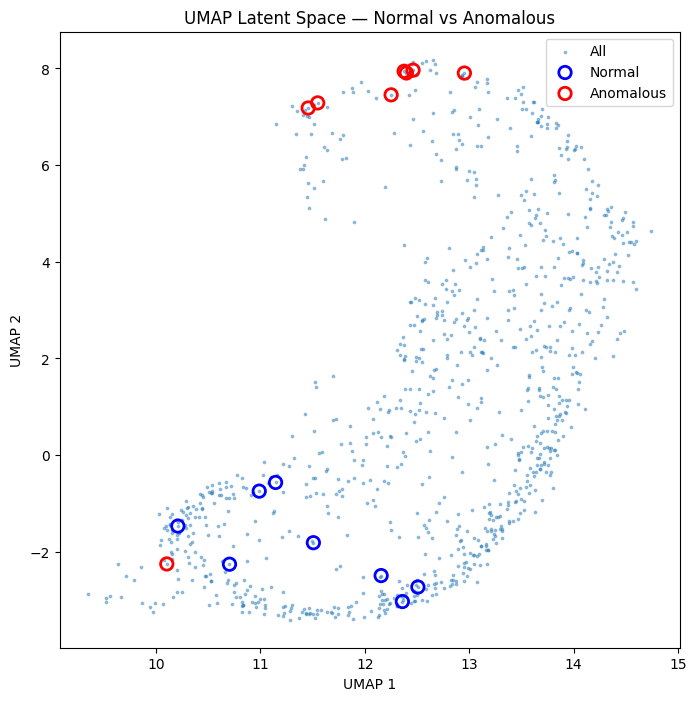

In [16]:
normal_umap = out[sorted_indices[:8]]
anomalous_umap = out[sorted_indices[-8:]]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(out[:, 0], out[:, 1], s=3, alpha=0.4, label="All")
ax.scatter(
    normal_umap[:, 0],
    normal_umap[:, 1],
    s=80,
    edgecolor="blue",
    facecolor="none",
    linewidths=2,
    label="Normal",
)
ax.scatter(
    anomalous_umap[:, 0],
    anomalous_umap[:, 1],
    s=80,
    edgecolor="red",
    facecolor="none",
    linewidths=2,
    label="Anomalous",
)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP Latent Space — Normal vs Anomalous")
ax.legend()
plt.show()

## What to take away

1. **The full Hyrax pipeline** — from data acquisition through anomaly discovery — can be driven entirely from a notebook with a handful of configuration calls and verbs.
2. **Vector databases** enable fast similarity search over the latent space. Hyrax stores inference results in Lance format, which supports efficient nearest-neighbour queries out of the box.
3. **Interactive visualization** with `h.visualize()` lets you lasso-select, tap, and inspect objects directly in the UMAP scatter plot.
4. **KNN distance** is a simple but effective anomaly score. The long tail of the distance histogram highlights objects that the model finds unusual.

Possible next steps:
- Perform clustering to search for additional sub-populations
- Filter out instrument artifacts and re-train
- Swap in a different model (e.g. `ImageDCAE` or your own custom model)
- Use [hyperparameter tuning](hyperparameter_tuning_examples.ipynb) to optimize model performance